# MPPI Metrics Analysis — Learned Cost Shaping vs Default Weights

Implements **Metrics 1–4 and 6** from the Empirical Analysis Plan (§3–§6, §8 of the PDF).

**Data:** `eval_sweep_50_tray_push/npz/`  
Active batch sizes: **{BATCH_SIZES}** — 5 seed runs × 10 episodes each → **50 episodes per method** per batch size.  
_(To include all batch sizes [250, 500, 750, 1000] → 200 episodes per method, update `BATCH_SIZES` in the config cell.)_

| Metric | Coverage | Notes |
|--------|----------|-------|
| M1 — Entropy $\bar{H}_t$ | ✅ §3 | formula verified |
| M2 — nESS | ✅ §4 | formula verified |
| M3 — CV | ✅ §5 | formula verified |
| M4 — Max weight ratio $r_t$ | ✅ §6 | formula verified |
| M5 — Perf vs batch size | ↗ separate notebook | `benchmark_ARS_batch.ipynb` |
| M6 — Weight trajectories | ✅ §8 | |
| M7 — Variance decomposition | ❌ §9 | needs per-component rollout costs $C_i^{(j)}$ not saved in NPZ |

**Plot style note:** PDF requests "averaged + confidence bands" for M1–3; this notebook  
draws one curve per episode (more informative — episode spread visible directly).

**Notation (§2)**
- $J^{(j)}$ : total cost of rollout $j$ at one MPC step — `cem_cost_batch[ep][step, j]`
- $N$ : effective batch size per episode (N_batch or maxiter × N_batch depending on CEM_ITER_MODE)
- $\lambda = 10$ : MPPI temperature (`self.lamda` in `mjx_planner.py`)
- $\tilde{w}_j = \exp(-J^{(j)}/\lambda)$ unnormalised importance weight
- $\hat{w}_j = \tilde{w}_j / \sum_{j'} \tilde{w}_{j'}$ normalised importance weight

All four normalised metrics ($\bar{H}$, nESS, CV, $r_t$) divide by $N$ or $\log N$, so they are **comparable across batch sizes**.

**Pick / lift phase split (`task_flag`)**  
`task_flag[t] = 0` = pick phase; `task_flag[t] = 1` = move/lift phase.  
For pre-existing NPZ files: derived per episode from `cost_g_pick < 0.03` (`grab_pos_thresh`) and `cost_r_pick < 0.05` (`grab_rot_thresh`).  
The switch step is **different for every episode** — phase masks are computed per-episode.


## 0 — Imports & config

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from pathlib import Path

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

SWEEP_ROOT = Path("eval_sweep_100_tray_push_8/npz")

# ── Batch sizes to include ────────────────────────────────────────────────────
# All available sizes: [250, 500, 750, 1000]
# Set BATCH_SIZES to any subset; each adds 100 episodes (5 seeds × 20 eps).
BATCH_SIZES = [250]          # active selection — change to [250, 500, 750, 1000] for full sweep

# For each method, collect sub-directories for the selected batch sizes.
SWEEP_DIRS = {
    "ARS":        [SWEEP_ROOT / f"policy_batch{bs}"    for bs in BATCH_SIZES],
    "Bayesian":   [SWEEP_ROOT / f"bayesian_batch{bs}"  for bs in BATCH_SIZES],
    "Hand-tuned": [SWEEP_ROOT / f"handtuned_batch{bs}" for bs in BATCH_SIZES],
}

# ── CEM iteration mode ────────────────────────────────────────────────────────
# "all"  : pool ALL CEM iterations → cem_cost_batch shape (n_steps, maxiter × N)
#          Treats every sample across all refinement rounds as one big batch.
# "last" : use only the FINAL CEM iteration → shape (n_steps, N)
#          Reflects the fully refined distribution (default PDF assumption).
# Change this and re-run the CEM-mode cell (cd_cem_mode) — no reload needed.
CEM_ITER_MODE = "all"
# CEM_ITER_MODE = "last"

LAMBDA = 10.0
COLORS = {"ARS": "#3498db", "Bayesian": "#2ecc71", "Hand-tuned": "#e74c3c"}


## 1 — Load & merge sweep data

All 20 seed files per method (4 batch sizes × 5 seeds) are merged into one 200-episode dataset.

`cem_cost_batch` is kept in raw form: shape `(n_steps, maxiter_cem, N)` per episode.  
The next cell (`cd_cem_mode`) converts it to `cem_cost_batch` according to `CEM_ITER_MODE`:

| Mode | Shape of `cem_cost_batch[ep]` | N used in metrics |
|------|-------------------------------|-------------------|
| `"all"` | `(n_steps, maxiter_cem × N)` | N_eff = maxiter × N_batch |
| `"last"` | `(n_steps, N)` | N_batch (original batch size) |

To switch modes: change `CEM_ITER_MODE` in the config cell and re-run **only** `cd_cem_mode`.


In [32]:
# ── Task-flag note ────────────────────────────────────────────────────────────
# `task_flag[t] = 0` during the *pick* phase (EEF approaching tray).
# `task_flag[t] = 1` during the *move* phase (EEF pushing tray to target).
# Saved directly from state["task"] in every tray-push NPZ.
# Thresholds that trigger the transition (for reference only):
#   grab_pos_thresh = 0.03  (both EEF positions must be < this)
#   grab_rot_thresh = 0.05  (both EEF rotations must be < this)
# ─────────────────────────────────────────────────────────────────────────────

GRAB_POS_THRESH = 0.03   # matches rl_trainer_batch.py: self.grab_pos_thresh
GRAB_ROT_THRESH = 0.05   # matches rl_trainer_batch.py: self.grab_rot_thresh


def load_sweep_dirs(dir_list):
    """
    Merge all seed NPZ files from a list of sweep sub-directories.
    cem_cost_batch is stored as (n_steps, maxiter_cem, N) per episode.
    The CEM-mode cell (cd_cem_mode) converts it to 2-D.
    """
    files = []
    for d in dir_list:
        files.extend(sorted(Path(d).glob("*.npz")))
    if not files:
        return None

    parts = [np.load(f, allow_pickle=True) for f in files]

    ep_1d  = ['success', 'total_time', 'reason']
    ep_obj = ['step_time', 'theta', 'thetadot',
              'cost_g_pick', 'cost_r_pick', 'cost_g_tray', 'cost_r_tray',
              'near_grasp', 'near_target', 'collision',
              'cost_weights', 'tray_target', 'task_flag',
              'cem_cost_batch']   # 3-D (n_steps, maxiter, N) per episode
    meta   = ['batch_size', 'horizon', 'cost_weight_keys']

    merged = {}
    for k in ep_1d:
        arrs = [p[k] for p in parts if k in p]
        if arrs:
            merged[k] = np.concatenate(arrs)
    for k in ep_obj:
        items = []
        for p in parts:
            if k in p:
                items.extend(p[k].tolist())
        if items:
            merged[k] = np.array(items, dtype=object)
    for k in meta:
        if k in parts[0]:
            merged[k] = parts[0][k]

    merged['batch_size_per_ep'] = np.array(
        [int(p['batch_size'][0]) for p in parts for _ in range(len(p['success']))]
    )

    return merged, files


def ep_arr(obj_arr, ep, dtype=np.float64):
    return np.array(obj_arr[ep], dtype=dtype)


# ── load ───────────────────────────────────────────────────────────────────────
data = {}
for label, dir_list in SWEEP_DIRS.items():
    result = load_sweep_dirs(dir_list)
    if result is None:
        print(f"[SKIP] {label}: no files found")
        continue
    merged, files = result
    data[label] = merged
    sr = merged["success"].mean() * 100
    n  = len(merged["success"])
    raw_shape = np.array(merged['cem_cost_batch'][0]).shape   # (n_steps, maxiter, N)
    tf_source = "saved in NPZ"
    print(f"{label:10s}  n_ep={n}  SR={sr:.1f}%  ({len(files)} files)")
    print(f"  cem_cost_batch[ep0] shape : {raw_shape}  "
          f"(n_steps x maxiter_cem x N_batch)")
    print(f"  task_flag source          : {tf_source}")

labels      = list(data.keys())
WEIGHT_KEYS = [str(k) for k in data[labels[0]].get("cost_weight_keys", [])]
CEM_COMP_KEYS = []
print("\nRun the CEM-mode cell (cd_cem_mode) next to build cem_cost_batch.")


ARS         n_ep=100  SR=60.0%  (5 files)
  cem_cost_batch[ep0] shape : (461, 1, 250)  (n_steps x maxiter_cem x N_batch)
  task_flag source          : saved in NPZ
Bayesian    n_ep=100  SR=32.0%  (5 files)
  cem_cost_batch[ep0] shape : (600, 1, 250)  (n_steps x maxiter_cem x N_batch)
  task_flag source          : saved in NPZ
Hand-tuned  n_ep=100  SR=15.0%  (5 files)
  cem_cost_batch[ep0] shape : (600, 1, 250)  (n_steps x maxiter_cem x N_batch)
  task_flag source          : saved in NPZ

Run the CEM-mode cell (cd_cem_mode) next to build cem_cost_batch.


In [33]:
# ── CEM iteration mode — re-run this cell whenever CEM_ITER_MODE changes ──────
#
# "all"  → pool all maxiter_cem rounds per step: shape (n_steps, maxiter × N)
#           N_eff = maxiter_cem × N_batch  (e.g. 3 × 250 = 750)
#
# "last" → final CEM iteration only: shape (n_steps, N)
#           Reflects the fully refined, most concentrated distribution.

def _build_cem_cost_batch(raw, mode):
    """raw: (n_steps, maxiter_cem, N) → 2-D array based on mode."""
    a = np.array(raw, dtype=np.float64)          # (n_steps, maxiter, N)
    if mode == "last":
        return a[:, -1, :]                        # (n_steps, N)
    else:                                         # "all"
        n_steps, maxiter, N = a.shape
        return a.reshape(n_steps, maxiter * N)    # (n_steps, maxiter*N)

for label in labels:
    d = data[label]
    if 'cem_cost_batch' not in d:
        print(f"[WARN] {label}: cem_cost_batch not found — skipping")
        continue
    # Preserve original 3-D (n_steps, maxiter, N) data before reshaping
    d['cem_batch_costs'] = d['cem_cost_batch']
    d['cem_cost_batch'] = np.array(
        [_build_cem_cost_batch(d['cem_batch_costs'][ep], CEM_ITER_MODE)
         for ep in range(len(d['cem_batch_costs']))],
        dtype=object,
    )

print(f"CEM_ITER_MODE = '{CEM_ITER_MODE}'")
print(f"{'Method':<12}  {'raw shape':>22}  →  {'cem_cost_batch[ep0]':>22}")
print("-" * 65)
for label in labels:
    d   = data[label]
    raw = np.array(d['cem_batch_costs'][0]).shape
    out = np.array(d['cem_cost_batch'][0]).shape
    n_steps, maxiter, N_base = raw
    N_eff = out[1]
    print(f"{label:<12}  {str(raw):>22}  →  {str(out):>22}"
          f"  (N_eff={N_eff})")


CEM_ITER_MODE = 'all'
Method                     raw shape  →     cem_cost_batch[ep0]
-----------------------------------------------------------------
ARS                    (461, 1, 250)  →              (461, 250)  (N_eff=250)
Bayesian               (600, 1, 250)  →              (600, 250)  (N_eff=250)
Hand-tuned             (600, 1, 250)  →              (600, 250)  (N_eff=250)


In [34]:
# Sanity check: keys, shapes, task_flag switch distribution
print(f"WEIGHT_KEYS ({len(WEIGHT_KEYS)}): {WEIGHT_KEYS}")
print()
for label in labels:
    d   = data[label]
    n   = len(d['success'])
    cb0 = np.array(d['cem_cost_batch']).shape
    bs  = sorted(set(d['batch_size_per_ep'].tolist()))
    switches = []
    for ep in range(n):
        tf = ep_arr(d['task_flag'], ep)
        sw = np.where(tf >= 0.5)[0]
        switches.append(int(sw[0]) if len(sw) else -1)
    sw_valid = [s for s in switches if s >= 0]
    no_grab  = sum(1 for s in switches if s < 0)
    print(f"{label:10s}  n_ep={n}  SR={d['success'].mean()*100:.1f}%  batch_sizes={bs}")
    print(f"  cem_cost_batch[ep0] shape : {cb0}  (n_episodes)")
    if sw_valid:
        print(f"  task_flag switch step     : min={min(sw_valid)}  "
              f"median={int(np.median(sw_valid))}  max={max(sw_valid)}  "
              f"no-grab eps={no_grab}")
    print()


WEIGHT_KEYS (12): ['collision', 'theta', 'eef_height_level', 'rot_axis_tray_alignment', 'eef_tray_rigid_body_velocity', 'position_pick', 'orientation_pick', 'distance', 'position_tray', 'orientation_tray', 'position_move', 'orientation_move']

ARS         n_ep=100  SR=60.0%  batch_sizes=[250]
  cem_cost_batch[ep0] shape : (100,)  (n_episodes)
  task_flag switch step     : min=62  median=79  max=346  no-grab eps=3

Bayesian    n_ep=100  SR=32.0%  batch_sizes=[250]
  cem_cost_batch[ep0] shape : (100,)  (n_episodes)
  task_flag switch step     : min=60  median=136  max=489  no-grab eps=9

Hand-tuned  n_ep=100  SR=15.0%  batch_sizes=[250]
  cem_cost_batch[ep0] shape : (100,)  (n_episodes)
  task_flag switch step     : min=49  median=271  max=567  no-grab eps=23



## 2 — MPPI weight helpers

In [35]:
# x = 1/2/3
# y = 1/(2*3)
# print(f"x = {x}, y = {y}, x==y? {x==y}")

## Rollout Cost Distribution at Selected Time Instants

Steps are sampled from pick / transition / lift phases using the **mean switch step averaged across all episodes and all methods** being plotted.

- For each episode that successfully grabbed the tray, record `sw` = first `t` where `task_flag[t] ≥ 0.5`
- `switch = round(mean(sw))` across those episodes
- `pick_pool` = steps before `switch − TRANS_WINDOW`
- `trans_pool` = steps within `±TRANS_WINDOW` of `switch`
- `lift_pool` = steps after `switch + TRANS_WINDOW`

`N_PICK / N_TRANS / N_MOVE` steps are evenly sampled from each pool.

**Normalization — per episode, per method:**

$$\bar{c}^{(j)} = \frac{c^{(j)} - c^{\text{ep}}_{\min}}{c^{\text{ep}}_{\max} - c^{\text{ep}}_{\min}}$$

where $c^{\text{ep}}_{\min}$ and $c^{\text{ep}}_{\max}$ are the min and max costs across **all steps × all rollouts of that episode**.  
Each episode is normalised independently, and methods are normalised independently.  
Values near 0 = lowest-cost rollouts within that episode's range; near 1 = highest-cost.

Background colour: 🔵 pick  🟠 transition  🟢 lift


In [36]:
import json as _json


def sample_pool(pool, n):
    if len(pool) == 0:
        return np.array([], dtype=int)
    idx = np.round(np.linspace(0, len(pool) - 1, min(n, len(pool)))).astype(int)
    return pool[idx]


# ════════════════════════════════════════════════════════════════════════════
# 1. STEP SELECTION — representative step indices for each phase (approach /
#    transition / move), based on the switch step averaged across every
#    episode and every method. Pure index selection — no cost data involved.
# ════════════════════════════════════════════════════════════════════════════

N_PICK       = 4    # steps sampled from approach phase
N_TRANS      = 2    # steps sampled from transition band
N_MOVE       = 4    # steps sampled from move phase
TRANS_WINDOW = 2    # half-width around switch defining "transition"

all_switches  = []
max_ep_len    = 0
per_method_sw = {}
for label in labels:
    d = data[label]
    sws = []
    for ep in range(len(d["success"])):
        task = ep_arr(d["task_flag"], ep)
        max_ep_len = max(max_ep_len, len(task))
        sw_idxs = np.where(task >= 0.5)[0]
        if len(sw_idxs):
            sws.append(int(sw_idxs[0]))
    per_method_sw[label] = sws
    all_switches.extend(sws)

assert all_switches, "No episode grabbed the tray — cannot determine average switch step"
switch  = int(round(np.mean(all_switches)))
ref_len = max_ep_len
n_grab  = len(all_switches)
n_total = sum(len(data[l]["success"]) for l in labels)

print("Switch step stats across all episodes:")
for label in labels:
    sws = per_method_sw[label]
    if sws:
        print(f"  {label:<12}  grabbed={len(sws)}  "
              f"min={min(sws)}  mean={int(round(np.mean(sws)))}  max={max(sws)}")
    else:
        print(f"  {label:<12}  grabbed=0 (no eps)")
print(f"  {'Overall':<12}  grabbed={n_grab}/{n_total}  "
      f"mean switch={switch}  range=[{min(all_switches)}, {max(all_switches)}]")
print(f"  max episode length: {ref_len}")

t_pick_end   = max(switch - TRANS_WINDOW - 1, 0)
t_move_start = switch + TRANS_WINDOW + 1

pick_pool  = np.arange(0, t_pick_end + 1)
trans_pool = np.arange(max(switch - TRANS_WINDOW, 0),
                       min(switch + TRANS_WINDOW + 1, ref_len))
move_pool  = np.arange(t_move_start, ref_len)

selected_pick  = sample_pool(pick_pool,  N_PICK)
selected_trans = sample_pool(trans_pool, N_TRANS)
selected_move  = sample_pool(move_pool,  N_MOVE)
selected = np.concatenate([selected_pick, selected_trans, selected_move])
phases   = (["approach"]   * len(selected_pick)
          + ["transition"] * len(selected_trans)
          + ["move"]       * len(selected_move))
print(f"\nSelected steps: pick={selected_pick.tolist()}  "
      f"trans={selected_trans.tolist()}  move={selected_move.tolist()}")


Switch step stats across all episodes:
  ARS           grabbed=97  min=62  mean=95  max=346
  Bayesian      grabbed=91  min=60  mean=172  max=489
  Hand-tuned    grabbed=77  min=49  mean=268  max=567
  Overall       grabbed=265/300  mean switch=172  range=[49, 567]
  max episode length: 600

Selected steps: pick=[0, 56, 113, 169]  trans=[170, 174]  move=[175, 316, 458, 599]


In [37]:
# ════════════════════════════════════════════════════════════════════════════
# 2. NORMALIZATION — the ONLY place raw rollout costs get normalised.
#    Every (method, episode, step, cem_iter) is min-max scaled independently,
#    using just the N rollouts at that (step, iter) — the batch axis is the
#    only one reduced over. CEM_ITER_MODE then pools iterations together
#    ("all") or keeps just the last one ("last") — a reshape, not a
#    renormalisation.
# ════════════════════════════════════════════════════════════════════════════

def normalize_per_step_iter(raw):
    """raw: (n_steps, maxiter, N) -> min-max normalised, same shape.
    min/max taken over N (last axis) for every (step, iter) independently."""
    s_min = raw.min(axis=-1, keepdims=True)
    s_max = raw.max(axis=-1, keepdims=True)
    denom = s_max - s_min
    return (raw - s_min) / denom

def pool_cem_iters(norm, mode):
    """norm: (n_steps, maxiter, N) normalised -> (n_steps, N_eff)."""
    if mode == "all":
        n_steps, maxiter, N = norm.shape
        return norm.reshape(n_steps, maxiter * N)
    return norm[:, -1, :]   # "last"

# ── overview: conceptual (method, episode, step, maxiter) shape ───────────────
#    step count and N can vary per episode, so this isn't one rectangular array —
#    printed as ranges per method instead.
print("Raw cost tensor per (method, episode): (n_steps, maxiter, N)")
print(f"  {'Method':<12}  {'n_ep':>5}  {'n_steps range':>16}  {'maxiter':>8}  {'N':>6}")
for l in labels:
    d = data[l]
    n_ep = len(d["success"])
    step_counts = [np.asarray(d["cem_batch_costs"][ep]).shape[0] for ep in range(n_ep)]
    sample = np.asarray(d["cem_batch_costs"][0])
    maxiter_l, N_l = sample.shape[1], sample.shape[2]
    print(f"  {l:<12}  {n_ep:>5}  [{min(step_counts):>5}, {max(step_counts):>5}]     "
          f"{maxiter_l:>8}  {N_l:>6}")
print(f"\nConceptual shape: (method={len(labels)}, episode~{n_ep} each, "
      f"step=ragged per episode, maxiter={maxiter_l})\n")

ep_norm_J = {}   # ep_norm_J[l][ep] : (n_steps, N_eff) fully normalised — the single source of truth
ep_stats  = {}   # ep_stats[l][ep]  : raw min/max/mean summary, for printing + JSON export only

_traced = False   # print a one-shot shape trace on the very first (method, ep) only

for l in labels:
    d = data[l]
    ep_norm_J[l] = []
    ep_stats[l]  = []
    for ep in range(len(d["success"])):
        raw = np.array(d["cem_batch_costs"][ep], dtype=np.float64)  # (n_steps, maxiter, N)
        maxiter = raw.shape[1]

        normed = normalize_per_step_iter(raw)
        pooled = pool_cem_iters(normed, CEM_ITER_MODE)
        ep_norm_J[l].append(pooled)

        if not _traced:
            _traced = True
            n_steps, _, N = raw.shape
            print(f"Shape pipeline (worked example: method={l!r}, ep={ep}):\n")
            print(f"  conceptual full tensor         (method, ep, step, maxiter, batch)  "
                  f"~ ({len(labels)}, n_ep, ragged, {maxiter}, {N})")
            print(f"  raw[method][ep]                (step, maxiter, batch)               = {raw.shape}")
            print(f"  normalize_per_step_iter(raw)   (step, maxiter, batch)               = {normed.shape}"
                  "   [min/max over batch axis only, per (step, maxiter)]")
            print(f"  pool_cem_iters(..., {CEM_ITER_MODE!r})       (step, batch_eff)                    = {pooled.shape}"
                  "   [maxiter folded into batch axis]")
            print(f"  ep_norm_J[method][ep][0]       (batch_eff,)                         = {pooled[0].shape}"
                  "   <- one planning step, all normalised rollouts\n")

        iters = [{"iter": it,
                  "min":  round(float(raw[:, it, :].min()),  4),
                  "max":  round(float(raw[:, it, :].max()),  4),
                  "mean": round(float(raw[:, it, :].mean()), 4)}
                 for it in range(maxiter)]
        ep_stats[l].append({
            "ep":      ep,
            "min":     round(float(raw.min()),  4),
            "max":     round(float(raw.max()),  4),
            "mean":    round(float(raw.mean()), 4),
            "success": bool(d["success"][ep]),
            "iters":   iters,
        })

print(f"\n ep_norm_J, {np.size(ep_norm_J)}")

# print("\nPer-episode cost stats (raw) with per-CEM-iteration breakdown:")
# print(f"  {'Method':<12}  {'ep':>4}  {'ok':>3}  "
#       f"{'ep_min':>10}  {'ep_max':>14}  {'ep_mean':>12}  | iters (min / max)")
# print("  " + "-" * 80)
for l in labels:
    for s in ep_stats[l]:
        iter_str = "  ".join(
            f"it{r['iter']}:[{r['min']:.1f},{r['max']:.1f}]"
            for r in s["iters"]
        )
        print(f"  {l:<12}  {s['ep']:>4}  {'✓' if s['success'] else '✗':>3}  "
              f"{s['min']:>10.2f}  {s['max']:>14.2f}  {s['mean']:>12.2f}  | {iter_str}")
    print()

# json_path = "ep_cost_stats.json"
# with open(json_path, "w") as f:
#     _json.dump({l: ep_stats[l] for l in labels}, f, indent=2)
# print(f"Saved → {json_path}")


# ════════════════════════════════════════════════════════════════════════════
# 3. Collect normalised rollout costs at each selected step
# ════════════════════════════════════════════════════════════════════════════

phase_colors = {"approach": "#cce5ff", "transition": "#ffe0b2", "move": "#c8e6c9"}

norm_costs  = {l: [] for l in labels}
ep_med_data = {l: [] for l in labels}
n_ep_used   = {l: [] for l in labels}

for l in labels:
    d  = data[l]
    ok = d["success"].astype(bool)
    for t in selected:
        pool = []
        meds = []
        for ep in range(len(d["success"])):
            J_norm = ep_norm_J[l][ep]          # (n_steps, N_eff) — already normalised
            if t >= len(J_norm):
                continue
            normed = J_norm[t]                 # (N_eff,)
            pool.append(normed)
            meds.append((float(np.median(normed)), bool(ok[ep])))
        norm_costs[l].append(np.concatenate(pool) if pool else np.array([np.nan]))
        ep_med_data[l].append(meds)
        n_ep_used[l].append(len(meds))


Raw cost tensor per (method, episode): (n_steps, maxiter, N)
  Method         n_ep     n_steps range   maxiter       N
  ARS             100  [  127,   600]            1     250
  Bayesian        100  [  208,   600]            1     250
  Hand-tuned      100  [  225,   600]            1     250

Conceptual shape: (method=3, episode~100 each, step=ragged per episode, maxiter=1)

Shape pipeline (worked example: method='ARS', ep=0):

  conceptual full tensor         (method, ep, step, maxiter, batch)  ~ (3, n_ep, ragged, 1, 250)
  raw[method][ep]                (step, maxiter, batch)               = (461, 1, 250)
  normalize_per_step_iter(raw)   (step, maxiter, batch)               = (461, 1, 250)   [min/max over batch axis only, per (step, maxiter)]
  pool_cem_iters(..., 'all')       (step, batch_eff)                    = (461, 250)   [maxiter folded into batch axis]
  ep_norm_J[method][ep][0]       (batch_eff,)                         = (250,)   <- one planning step, all normalised roll


 ep_norm_J, 1
  ARS              0    ✗       38.56        18399.50        803.94  | it0:[38.6,18399.5]
  ARS              1    ✓       37.43        14555.28        526.67  | it0:[37.4,14555.3]
  ARS              2    ✓       44.08        12920.55        641.19  | it0:[44.1,12920.6]
  ARS              3    ✓       56.18        16877.55        637.99  | it0:[56.2,16877.6]
  ARS              4    ✓       41.35        22554.95       1052.76  | it0:[41.3,22554.9]
  ARS              5    ✓       37.05        12923.65        604.89  | it0:[37.0,12923.6]
  ARS              6    ✓       38.66        12911.35        474.20  | it0:[38.7,12911.3]
  ARS              7    ✗       41.90        13497.73        898.49  | it0:[41.9,13497.7]
  ARS              8    ✓       37.94        17490.32        721.01  | it0:[37.9,17490.3]
  ARS              9    ✗       41.19        24529.49       1726.12  | it0:[41.2,24529.5]
  ARS             10    ✓       38.83        13449.47        586.48  | it0:[38.8,1344

### Violin plots of normalised rollout costs at selected steps

In [38]:
LOW_THRESH = 0.25   # fraction of rollouts below this normalised cost counts as "good"



In [39]:
# ── Per-method rollout cost violins with per-method phase boundaries ───────────
# Problem with the shared-switch plot: step t=45 may be pick for ARS
# (whose avg switch=55) but move for Hand-tuned (avg switch=40).
# Fix: each method row selects its own representative steps using that
# method's own average switch step.

_N_PICK  = 4
_N_TRANS = 1
_N_MOVE  = 2
_TW      = 1
_N_TOTAL = _N_PICK + _N_TRANS + _N_MOVE

from scipy.stats import norm as _norm
CI_LEVEL = 0.7                                  # ← change to 0.90, 0.99, etc.
CI_Z     = _norm.ppf(1 - (1 - CI_LEVEL) / 2)     # two-sided z-score
print(f"CI_LEVEL={CI_LEVEL:.0%}  z={CI_Z:.4f}")

# ── per-method step selection based on that method's own avg switch ────────────
method_switch    = {}   # per-method average switch step
method_selected  = {}   # per-method selected step indices
method_phases    = {}   # per-method phase labels
method_nc        = {}   # per-method normalized costs at selected steps
method_bounds    = {}   # per-method (pick_end, m_sw, move_start, ci_margin, m_std)

for l in labels:
    sws = per_method_sw.get(l, [])
    m_std = float(np.std(sws)) if len(sws) > 1 else 0.0
    print(f"\nMethod {l} switch steps:  min={min(sws)}  mean={int(round(np.mean(sws))) if sws else 'N/A'}  max={max(sws)}  std={m_std:.1f}  n={len(sws)}")
    m_sw  = int(round(np.mean(sws))) if sws else switch   # fallback to global
    method_switch[l] = m_sw

    m_ref = max(len(ep_norm_J[l][ep]) for ep in range(len(data[l]["success"])))
    # CI: steps guaranteed to be in pick / move across all episodes
    ci_margin  = int(np.ceil(CI_Z * m_std))
    pick_end   = max(m_sw - ci_margin - 1, 0)   # last step safely in approach phase
    move_start = m_sw + ci_margin + 1            # first step safely in move phase
    print(f"  pick_end={pick_end}  m_sw={m_sw}  move_start={move_start}  (ci_margin={ci_margin})")
    method_bounds[l] = (pick_end, m_sw, move_start, ci_margin, m_std)

    p_pool = np.arange(0, pick_end + 1)
    m_pool = np.arange(move_start, m_ref)

    sel_p = sample_pool(p_pool, _N_PICK)
    t_pool = np.arange(max(m_sw - _TW, 0), min(m_sw + _TW + 3, m_ref))
    sel_t = sample_pool(t_pool, _N_TRANS)
    sel_m = sample_pool(m_pool, _N_MOVE)
    sel   = np.concatenate([sel_p, sel_t, sel_m])
    phs   = (["approach"]       * len(sel_p)
           + ["transition"] * len(sel_t)
           + ["move"]       * len(sel_m))

    method_selected[l] = sel
    method_phases[l]   = phs

    # collect normalised costs
    d  = data[l]

    nc = []
    for t in sel:
        pool = []
        for ep in range(len(d["success"])):
            J_norm = ep_norm_J[l][ep]
            if t >= len(J_norm):
                continue
            pool.append(J_norm[t])
        nc.append(np.concatenate(pool) if pool else np.array([np.nan]))
    method_nc[l] = nc


# ── Phase boundary table ───────────────────────────────────────────────────────
print(f"\n{'Method':<14} {'mean_sw':>8} {'std_sw':>8} {'CI_margin':>10} {'pick_end':>10} {'move_start':>11}")
print("-" * 70)
for l in labels:
    pe, msw, ms, cim, mstd = method_bounds[l]
    print(f"  {l:<12}  {msw:>8}  {mstd:>8.1f}  {cim:>10}  {pe:>10}  {ms:>11}")
print("-" * 70)
print("  pick steps ∈ [0, pick_end]  |  move steps ∈ [move_start, ep_end]")
print(f"  CI_margin = ceil(CI_Z × std)  →  {CI_LEVEL:.0%} of switch steps fall in [mean±margin]  (CI_Z={CI_Z:.3f})")

print("\nSelected step indices per method:")
for l in labels:
    print(f"  {l:<12}  switch≈{method_switch[l]}  "
          f"pick={[x for x,p in zip(method_selected[l], method_phases[l]) if p=='approach']}  "
          f"transition={[x for x,p in zip(method_selected[l], method_phases[l]) if p=='transition']}  "
          f"move={[x for x,p in zip(method_selected[l], method_phases[l]) if p=='move']}")



CI_LEVEL=70%  z=1.0364

Method ARS switch steps:  min=62  mean=95  max=346  std=45.0  n=97
  pick_end=47  m_sw=95  move_start=143  (ci_margin=47)

Method Bayesian switch steps:  min=60  mean=172  max=489  std=91.5  n=91
  pick_end=76  m_sw=172  move_start=268  (ci_margin=95)

Method Hand-tuned switch steps:  min=49  mean=268  max=567  std=160.9  n=77
  pick_end=100  m_sw=268  move_start=436  (ci_margin=167)

Method          mean_sw   std_sw  CI_margin   pick_end  move_start
----------------------------------------------------------------------
  ARS                 95      45.0          47          47          143
  Bayesian           172      91.5          95          76          268
  Hand-tuned         268     160.9         167         100          436
----------------------------------------------------------------------
  pick steps ∈ [0, pick_end]  |  move steps ∈ [move_start, ep_end]
  CI_margin = ceil(CI_Z × std)  →  70% of switch steps fall in [mean±margin]  (CI_Z=1.036)

Sele

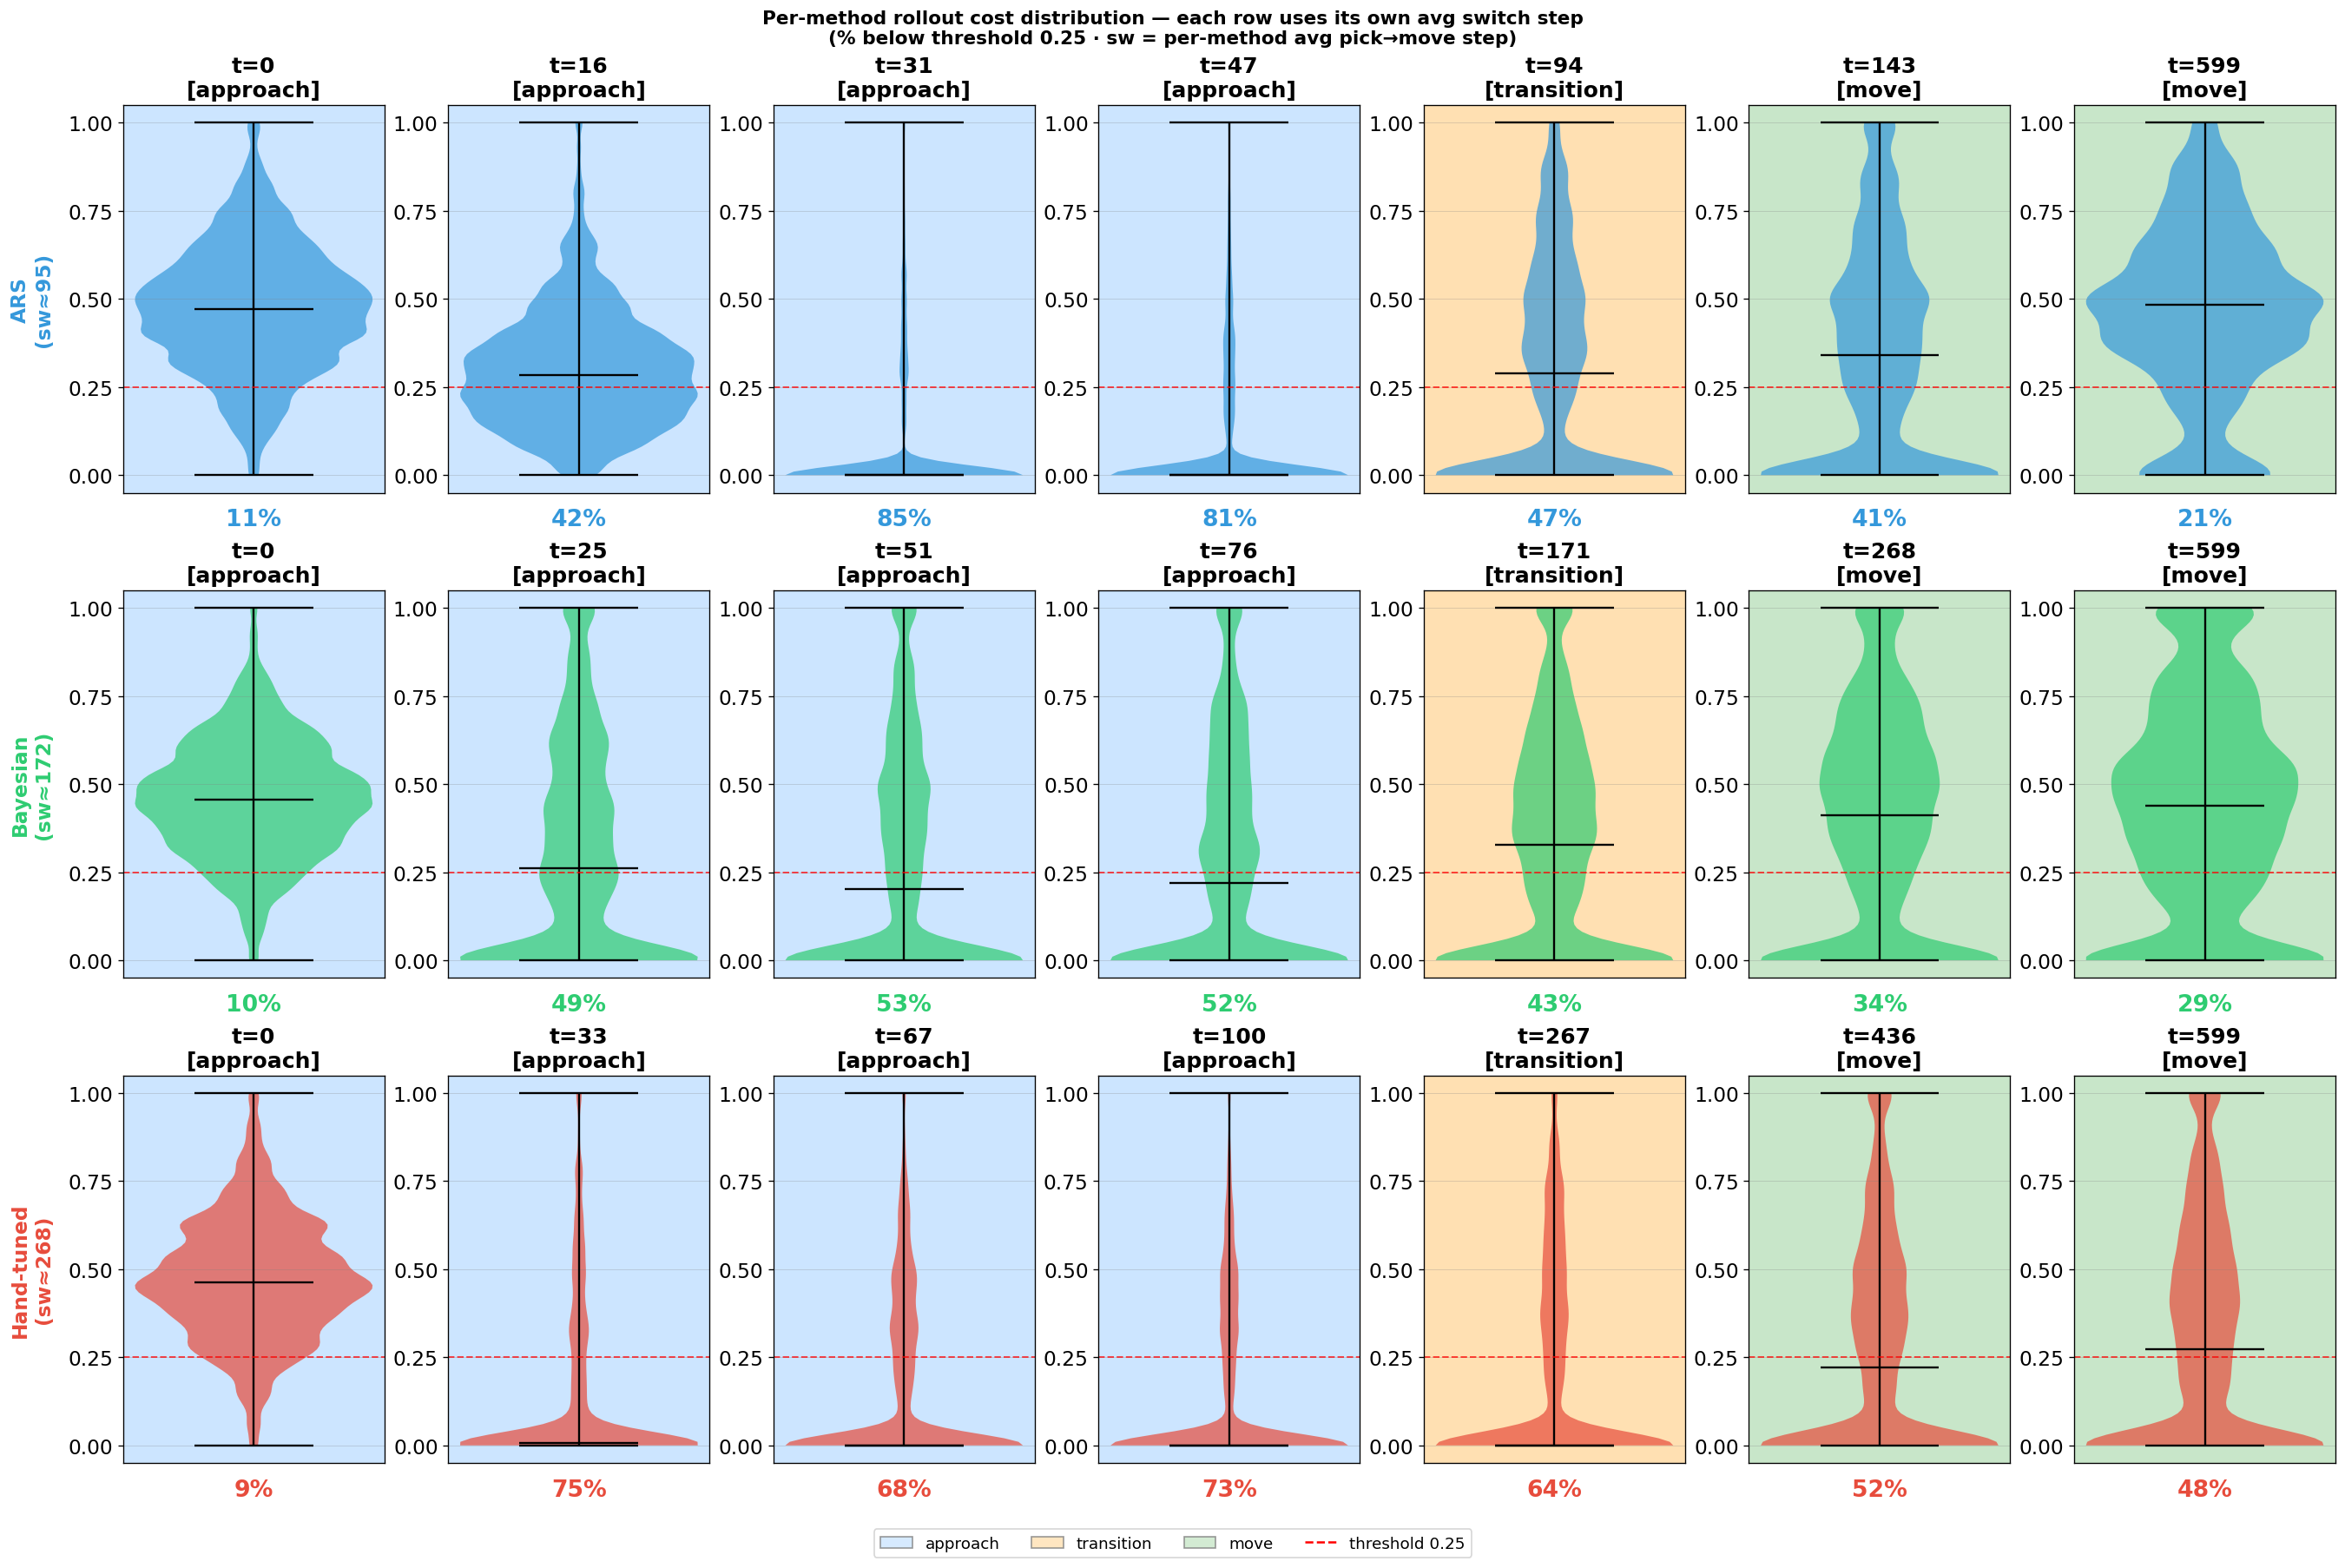

In [40]:

# ── plot: one row per method ───────────────────────────────────────────────────
n_rows = len(labels)
fig, axes_grid = plt.subplots(n_rows, _N_TOTAL,
                               figsize=(_N_TOTAL * 3.2, n_rows * 4.8),
                               constrained_layout=True)
if n_rows == 1:
    axes_grid = [axes_grid]

for row, l in enumerate(labels):
    sel = method_selected[l]
    phs = method_phases[l]
    nc  = method_nc[l]
    axs = axes_grid[row]

    for si, (t, ph, ax) in enumerate(zip(sel, phs, axs)):
        ax.set_facecolor(phase_colors[ph])
        vals = nc[si][~np.isnan(nc[si])]

        if len(vals) == 0:
            ax.set_visible(False)
            continue

        parts = ax.violinplot([vals], positions=[0],
                              showmedians=True, showextrema=True, widths=0.65)
        parts["bodies"][0].set_facecolor(COLORS.get(l, "gray"))
        parts["bodies"][0].set_alpha(0.7)
        for part in ("cmedians", "cmins", "cmaxes", "cbars"):
            parts[part].set_color("black")
            parts[part].set_linewidth(1.4)

        ax.axhline(LOW_THRESH, color="red", lw=1.2, ls="--", alpha=0.7)

        pct = 100.0 * np.mean(vals < LOW_THRESH)
        ax.text(0, -0.04, f"{pct:.0f}%",
                ha="center", va="top", fontsize=16, fontweight="bold",
                color=COLORS.get(l, "black"),
                transform=ax.get_xaxis_transform())

        ax.set_title(f"t={t}\n[{ph}]", fontsize=15, fontweight="bold")
        ax.set_ylim(-0.05, 1.05)
        ax.tick_params(axis="y", labelsize=14)
        ax.set_xticks([])
        ax.yaxis.set_major_locator(plt.MultipleLocator(0.25))
        ax.grid(axis="y", lw=0.4, color="gray", alpha=0.4)

    # hide any unused axes in this row
    for si in range(len(sel), _N_TOTAL):
        axs[si].set_visible(False)

    # row label on the left
    axs[0].set_ylabel(
        f"{l}\n(sw≈{method_switch[l]})",
        fontsize=14, fontweight="bold",
        color=COLORS.get(l, "black"), labelpad=10
    )

from matplotlib.patches import Patch
from matplotlib.lines   import Line2D
fig.legend(
    handles=(
        [Patch(facecolor=phase_colors[p], edgecolor="gray", alpha=0.8, label=p)
         for p in ("approach", "transition", "move")]
        + [Line2D([0],[0], color="red", lw=1.5, ls="--", label=f"threshold {LOW_THRESH}")]
    ),
    loc="lower center", ncol=4, fontsize=11,
    frameon=True, bbox_to_anchor=(0.5, -0.04)
)
fig.suptitle(
    "Per-method rollout cost distribution — each row uses its own avg switch step\n"
    f"(% below threshold {LOW_THRESH} · sw = per-method avg pick→move step)",
    fontsize=13, fontweight="bold"
)
plt.show()
